# Perceptron — The Building Block of Neural Networks

## Goal
Understand how a single neuron learns to classify data.
Before neural networks, before deep learning — there was the perceptron.

## Key Questions
- How does a neuron make a decision?
- What is a weight and why does it matter?
- How does the perceptron update its weights?

## What We Build
A perceptron from scratch using only numpy — no PyTorch yet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. What is a Perceptron?

A perceptron takes inputs, multiplies them by weights, adds a bias,
and passes the result through an activation function.

```
inputs → weighted sum → activation → output
x1, x2 → w1*x1 + w2*x2 + b → step function → 0 or 1
```

In [10]:
class Perceptron:
    """
    Single neuron classifier - the foundation of neural networks.

    Learn a linear decision boundary using the perceptron learning rule
    """

    def __init__(self, learning_rate: float = 0.1, epochs: int = 100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors = []

    def _activation(self, x: float) -> int:
        """Step function - output is 0 or 1."""
        return 1 if x >= 0 else 0

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """Train the perceptron using the perceptron learning rule.
        
        Args:
            X: Training data (n_sample, n_features)
            y: Labels (n_samples,) - must be 0 or 1
        """
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = -0.2

        for epoch in range(self.epochs):
            errors = 0
            for xi, yi in zip(X, y):
                prediction = self._activation(np.dot(xi, self.weights) + self.bias)
                update = self.learning_rate * (yi - prediction)
                self.weights += update * xi
                self.weights += update
                errors += int(update != 0)
            self.errors.append(errors)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict class labels for samples in X."""
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([self._activation(x) for x in linear_output])

    def accuracy(self, X: np.ndarray, y: np.ndarray) -> float:
        """Calculate prediction accuracy."""
        predictions = self.predict(X)
        return np.mean(predictions == y)


print("Perceptron class defined.")

Perceptron class defined.


## 2. Train on AND Gate
The AND gate is linearly separable — a perfect test for the perceptron.

In [13]:
# AND gate dataset
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

# Train with shuffle
np.random.seed(42)
perceptron = Perceptron(learning_rate=0.01, epochs=1000)
perceptron.bias = 0
perceptron.weights = np.zeros(2)

for epoch in range(1000):
    idx = np.random.permutation(len(X_and))
    errors = 0
    for i in idx:
        xi, yi = X_and[i], y_and[i]
        pred = perceptron._activation(np.dot(xi, perceptron.weights) + perceptron.bias)
        update = 0.01 * (yi - pred)
        perceptron.weights += update * xi
        perceptron.bias += update
        errors += int(update != 0)
    perceptron.errors.append(errors)

print("And Gate Results:")
print(f"{"Input":<15} {"Expected":>10} {"Predict":>10}")
print("-" * 37)
for xi, yi in zip(X_and, y_and):
    pred = perceptron.predict([xi])[0]
    print(f"{str(xi):<15} {yi:>10} {pred:>10}")

print(f"\nAccuracy: {perceptron.accuracy(X_and, y_and):.0%}")

And Gate Results:
Input             Expected    Predict
-------------------------------------
[0 0]                    0          0
[0 1]                    0          0
[1 0]                    0          0
[1 1]                    1          1

Accuracy: 100%


## 3. Visualize Decision Boundary

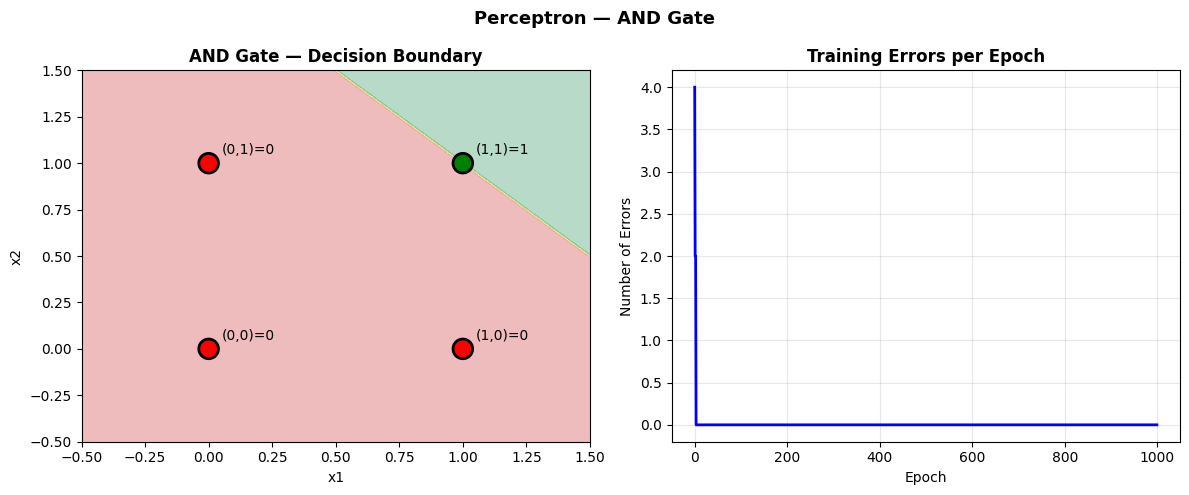

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Decision boundary
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = perceptron.predict(grid).reshape(xx.shape)

axes[0].contourf(xx, yy, Z, alpha=0.3, cmap="RdYlGn")
colors = ["red" if yi == 0 else "green" for yi in y_and]
axes[0].scatter(X_and[:, 0], X_and[:, 1], c=colors, s=200, 
               edgecolors="black", linewidth=2, zorder=5)

for xi, yi in zip(X_and, y_and):
    axes[0].annotate(f'({xi[0]},{xi[1]})={yi}', 
                    xy=(xi[0], xi[1]), 
                    xytext=(xi[0]+0.05, xi[1]+0.05), fontsize=10)

axes[0].set_title("AND Gate — Decision Boundary", fontsize=12, fontweight="bold")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

# Chart 2 — Training errors
axes[1].plot(perceptron.errors, color="blue", linewidth=2)
axes[1].set_title("Training Errors per Epoch", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Number of Errors")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Perceptron — AND Gate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("perceptron_and.png", dpi=300)
plt.show()

## 4. XOR Problem — Where Perceptron Fails

XOR is not linearly separable.
A single perceptron cannot solve it — this limitation led to neural networks.

In [17]:
# XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Train
xor_perceptron = Perceptron(learning_rate=0.01, epochs=1000)
xor_perceptron.weights = np.zeros(2)
xor_perceptron.bias = 0

for epoch in range(1000):
    idx = np.random.permutation(len(X_xor))
    errors = 0
    for i in idx:
        xi, yi = X_xor[i], y_xor[i]
        pred = xor_perceptron._activation(np.dot(xi, xor_perceptron.weights) + xor_perceptron.bias)
        update = 0.01 * (yi - pred)
        xor_perceptron.weights += update * xi
        xor_perceptron.bias += update
        errors += int(update != 0)
    xor_perceptron.errors.append(errors)

print("XOR Gate Result:")
print(f"{"Input":<15} {"Expected":>10} { "Predicted":>10}")
print("-" * 37)
for xi, yi in zip(X_xor, y_xor):
    pred = xor_perceptron.predict([xi])[0]
    print(f"{str(xi):<15} {yi:>10} {pred:>10}")

print(f"\nAccuracy: {xor_perceptron.accuracy(X_xor, y_xor):.0%}")
print("\nA single perceptron cannot solve XOR - it is not linearly separable.")
print("This is why we need neural networks with hidden layers.")

XOR Gate Result:
Input             Expected  Predicted
-------------------------------------
[0 0]                    0          0
[0 1]                    1          0
[1 0]                    1          0
[1 1]                    0          0

Accuracy: 50%

A single perceptron cannot solve XOR - it is not linearly separable.
This is why we need neural networks with hidden layers.


## 5. Key Observations

| Problem | Linearly Separable? | Perceptron Accuracy |
|---------|--------------------|--------------------|
| AND | Yes | 100% |
| XOR | No | 50% |

## Key Insight
A perceptron can only learn a linear decision boundary.
AND gate: one straight line can separate 0s from 1s ✓
XOR gate: no straight line can separate 0s from 1s ✗

This limitation motivated the invention of multi-layer neural networks.
Adding hidden layers allows the network to learn non-linear boundaries.

## What I Learned
Weights determine the slope of the decision boundary.
Bias determines where the boundary is positioned.
The perceptron learning rule adjusts both until the boundary separates the classes.
When no linear boundary exists, the perceptron oscillates forever — never converges.

## Next
How do multiple layers solve the XOR problem?
-> 02_neural_network.ipynb